# DAF-03: Delhi Station and Sensor Discovery

We are checking which Delhi locations report PM2.5 and what other sensors exist at each location. We will collect every location and every sensor, then create a separate PM2.5 table for the station-selection decision.

## 1. Load the project configuration

The API key stays in `.env` instead of inside this notebook. This keeps the secret out of the code and out of Git. We only print whether the key exists, never the key itself.

In [1]:
import os
import time
from pathlib import Path

import pandas as pd
import requests
from dotenv import load_dotenv

project_root = Path.cwd().parent
load_dotenv(project_root / ".env")

api_key = os.getenv("OPENAQ_API_KEY")
if not api_key:
    raise RuntimeError("OPENAQ_API_KEY is missing from the project .env file")

headers = {"X-API-Key": api_key}
locations_url = "https://api.openaq.org/v3/locations"

print("API key loaded:", bool(api_key))

API key loaded: True


## 2. Create one reusable API request helper

We will call OpenAQ many times. Keeping the HTTP and error handling in one function prevents us from repeating the same checks in every request.

- `401` means the key is missing or invalid, so we stop.
- `429` means too many requests, so we wait and retry.
- `200` means the request succeeded.

In [2]:
def request_json(url, params=None, max_retries=3):
    for attempt in range(max_retries):
        response = requests.get(
            url,
            headers=headers,
            params=params,
            timeout=30,
        )

        if response.status_code == 200:
            return response.json()

        if response.status_code == 401:
            raise RuntimeError("Authentication failed: check the OpenAQ API key")

        if response.status_code == 429:
            wait_seconds = 10 * (attempt + 1)
            print(f"Rate limit reached. Waiting {wait_seconds} seconds.")
            time.sleep(wait_seconds)
            continue

        raise RuntimeError(
            f"OpenAQ request failed with HTTP {response.status_code}: "
            f"{response.text[:200]}"
        )

    raise RuntimeError("OpenAQ request failed after several retries")

## 3. Fetch all Delhi locations

The API returns at most 100 locations per page. The first request returned 100 and reported more than 100, so we must continue with page 2 and any later pages. Stopping after page 1 would silently lose locations.

In [3]:
all_delhi_locations = []
page = 1
page_size = 100

while True:
    page_params = {
        "bbox": "76.80,28.40,77.40,28.90",
        "parameters_id": 2,
        "limit": page_size,
        "page": page,
    }

    page_payload = request_json(locations_url, params=page_params)
    page_locations = page_payload["results"]
    all_delhi_locations.extend(page_locations)

    print(f"Page {page}: {len(page_locations)} locations")

    if len(page_locations) < page_size:
        break

    page += 1
    time.sleep(1)

print("Total locations collected:", len(all_delhi_locations))

Page 1: 100 locations
Page 2: 2 locations
Total locations collected: 102


## 4. Fetch every sensor at every location

A location is a monitoring station. A station can have several sensors: PM2.5, NO2, ozone, and others. We keep every sensor so the table shows the complete picture, including first and last reading times.

In [4]:
all_sensor_records = []

for index, location in enumerate(all_delhi_locations, start=1):
    location_id = location["id"]
    sensors_url = f"https://api.openaq.org/v3/locations/{location_id}/sensors"
    sensors_payload = request_json(sensors_url)
    sensors = sensors_payload["results"]

    coordinates = location.get("coordinates") or {}
    provider = location.get("provider")
    if isinstance(provider, dict):
        provider = provider.get("name")

    for sensor in sensors:
        parameter = sensor.get("parameter") or {}
        first_reading = sensor.get("datetimeFirst") or {}
        last_reading = sensor.get("datetimeLast") or {}

        all_sensor_records.append(
            {
                "location_id": location_id,
                "sensor_id": sensor.get("id"),
                "location_name": location.get("name"),
                "parameter": parameter.get("name"),
                "latitude": coordinates.get("latitude"),
                "longitude": coordinates.get("longitude"),
                "provider": provider,
                "first_reading": first_reading.get("local"),
                "last_reading": last_reading.get("local"),
            }
        )

    if index % 10 == 0 or index == len(all_delhi_locations):
        print(
            f"Processed {index}/{len(all_delhi_locations)} locations; "
            f"sensor rows collected: {len(all_sensor_records)}"
        )

    time.sleep(1)

print("Total sensor records:", len(all_sensor_records))

Processed 10/102 locations; sensor rows collected: 99
Rate limit reached. Waiting 10 seconds.
Processed 20/102 locations; sensor rows collected: 175
Processed 30/102 locations; sensor rows collected: 305
Processed 40/102 locations; sensor rows collected: 377
Rate limit reached. Waiting 10 seconds.
Rate limit reached. Waiting 20 seconds.
Processed 50/102 locations; sensor rows collected: 441
Processed 60/102 locations; sensor rows collected: 621
Processed 70/102 locations; sensor rows collected: 764
Processed 80/102 locations; sensor rows collected: 914
Processed 90/102 locations; sensor rows collected: 1036
Processed 100/102 locations; sensor rows collected: 1130
Processed 102/102 locations; sensor rows collected: 1154
Total sensor records: 1154


## 5. Display all locations and sensors

A DataFrame gives us a readable table instead of only progress messages. The first table contains every sensor. The second table contains only PM2.5 rows for the station coverage decision.

In [5]:
all_sensors_table = pd.DataFrame(all_sensor_records)

print("Rows in sensor table:", len(all_sensors_table))
print("Locations in sensor table:", all_sensors_table["location_id"].nunique())

display(
    all_sensors_table
    .sort_values(["location_id", "parameter"])
    .reset_index(drop=True)
)

pm25_table = all_sensors_table[
    all_sensors_table["parameter"].fillna("").str.lower() == "pm25"
].copy()

print("PM2.5 rows:", len(pm25_table))
display(pm25_table.sort_values("location_id").reset_index(drop=True))

Rows in sensor table: 1154
Locations in sensor table: 102


,location_id,sensor_id,location_name,parameter,latitude,longitude,provider,first_reading,last_reading
0,13,13866,"Delhi Technological University, Delhi - CPCB",no2,28.744000,77.120000,CPCB,2016-11-03T00:30:00+05:30,2018-02-22T09:30:00+05:30
1,13,24,"Delhi Technological University, Delhi - CPCB",o3,28.744000,77.120000,CPCB,None,None
2,13,13864,"Delhi Technological University, Delhi - CPCB",pm25,28.744000,77.120000,CPCB,2016-11-03T00:30:00+05:30,2018-02-22T09:30:00+05:30
3,15,27,IGI Airport,co,28.560000,77.094000,CPCB,None,None
4,15,28,IGI Airport,no2,28.560000,77.094000,CPCB,None,None
...,...,...,...,...,...,...,...,...,...
1149,6299678,15890342,"Ved Vihar-Loni, Ghaziabad - UPPCB",relativehumidity,28.739153,77.273668,N/A,2026-04-07T22:30:00+05:30,2026-09-11T16:00:00+05:30
1150,6299678,15890343,"Ved Vihar-Loni, Ghaziabad - UPPCB",so2,28.739153,77.273668,N/A,2026-04-07T22:30:00+05:30,2026-09-11T16:00:00+05:30
1151,6299678,15890344,"Ved Vihar-Loni, Ghaziabad - UPPCB",temperature,28.739153,77.273668,N/A,2026-04-07T22:30:00+05:30,2026-09-11T16:00:00+05:30
1152,6299678,15890345,"Ved Vihar-Loni, Ghaziabad - UPPCB",wind_direction,28.739153,77.273668,N/A,2026-04-07T22:30:00+05:30,2026-09-11T16:00:00+05:30


PM2.5 rows: 147


,location_id,sensor_id,location_name,parameter,latitude,longitude,provider,first_reading,last_reading
0,13,13864,"Delhi Technological University, Delhi - CPCB",pm25,28.744000,77.120000,CPCB,2016-11-03T00:30:00+05:30,2018-02-22T09:30:00+05:30
1,15,30,IGI Airport,pm25,28.560000,77.094000,CPCB,None,None
2,16,34,Civil Lines,pm25,28.678700,77.226200,CPCB,None,None
3,17,12234787,"R K Puram, Delhi - DPCC",pm25,28.563262,77.186937,CPCB,2025-02-19T01:45:00+05:30,2026-09-11T15:45:00+05:30
4,17,35,"R K Puram, Delhi - DPCC",pm25,28.563262,77.186937,CPCB,2016-02-05T20:25:00+05:30,2018-02-22T02:45:00+05:30
...,...,...,...,...,...,...,...,...,...
142,6254665,15554728,"Commonwealth Sports Complex, Delhi - DPCC",pm25,28.615828,77.271992,N/A,2026-02-27T22:30:00+05:30,2026-09-11T16:00:00+05:30
143,6254666,15554740,"IGNOU_Maidan Garhi, Delhi - DPCC",pm25,28.493624,77.201159,N/A,2026-02-27T22:30:00+05:30,2026-09-11T16:00:00+05:30
144,6257818,15578291,"Cantonment Area, Delhi - DPCC",pm25,28.594169,77.125100,N/A,2026-03-02T18:30:00+05:30,2026-09-11T14:30:00+05:30
145,6299494,15888918,"Prashant Garden, Khora - UPPCB",pm25,28.611190,77.342060,N/A,2026-04-07T18:15:00+05:30,2026-09-11T16:00:00+05:30


# Recap — Notebook 02 in one picture

This notebook asks the API a simple question: which Delhi locations measure PM2.5, and what sensors do they carry? The pictures below put the answer on one page.

```text
API key -> request helper -> all location pages -> sensors at each location -> two tables
 (secret)   (401/429/200)      100 + 2 = 102           1,154 sensor rows       1,154 and 147
```

**How to read the pictures**

- **Picture 1, the journey.** Six cards, one per step. Each shows the count going in and out. The blue card is where the notebook ends.
- **Picture 2, the evidence.** Who runs the sensors, how many PM2.5 sensors each location has, and when the sensors started and stopped.
- **Where the numbers come from.** The pages, the 102 locations and the 1,154 sensor rows are the counts this notebook printed. The 147 PM2.5 sensors are read from `data/raw/stations.csv`. The API is not called again.

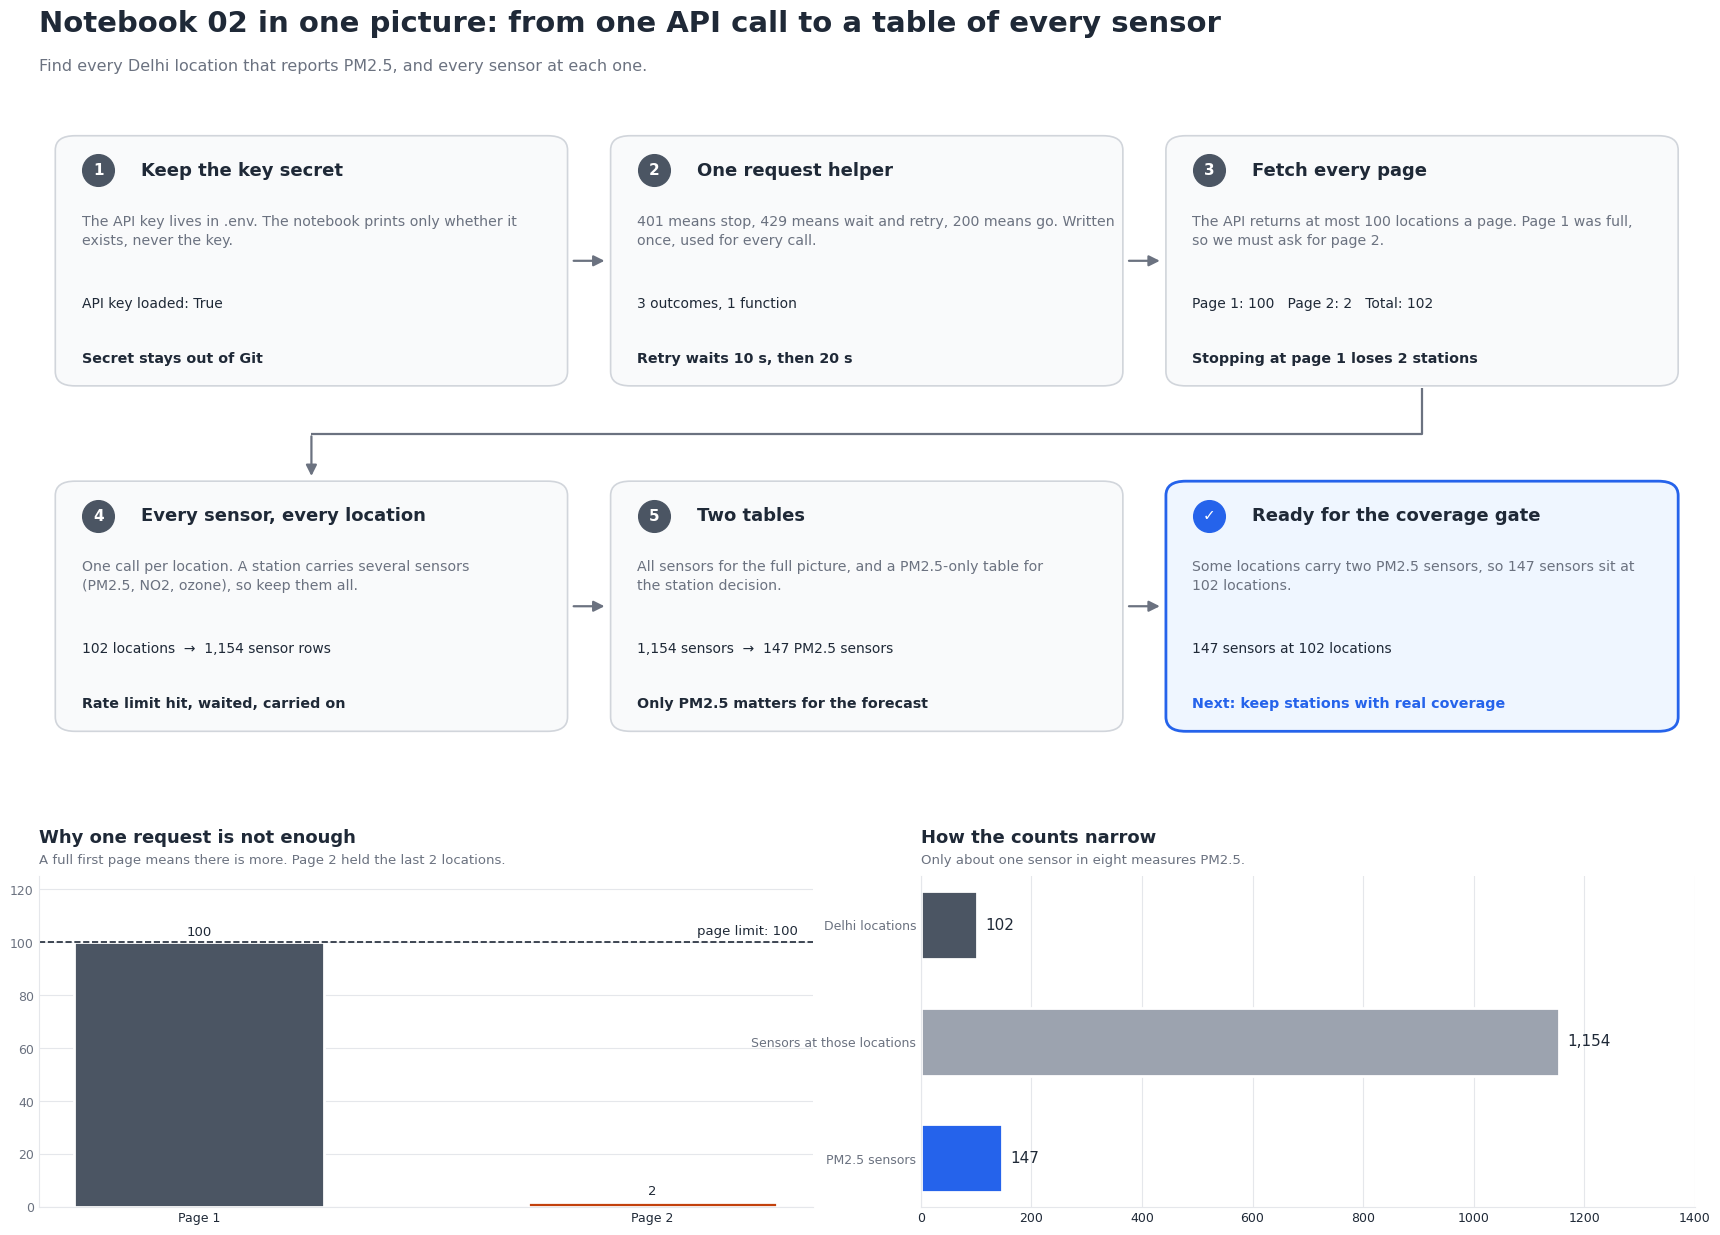

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

import recap_style as rs

root = rs.find_project_root()
pm25_sensors = pd.read_csv(root / "data/raw/stations.csv")

# These three numbers are printed by the notebook itself; the API is not called again.
page_sizes = [100, 2]
all_sensor_rows = 1154
locations = sum(page_sizes)
pm25_rows = len(pm25_sensors)
assert pm25_sensors["location_id"].nunique() == locations, "stations.csv no longer matches the notebook's 102 locations"

cards = [
    dict(badge="1", title="Keep the key secret", adds="The API key lives in .env. The notebook prints only whether it exists, never the key.",
         numbers="API key loaded: True", verdict="Secret stays out of Git"),
    dict(badge="2", title="One request helper", adds="401 means stop, 429 means wait and retry, 200 means go. Written once, used for every call.",
         numbers="3 outcomes, 1 function", verdict="Retry waits 10 s, then 20 s"),
    dict(badge="3", title="Fetch every page", adds="The API returns at most 100 locations a page. Page 1 was full, so we must ask for page 2.",
         numbers=f"Page 1: {page_sizes[0]}   Page 2: {page_sizes[1]}   Total: {locations}", verdict="Stopping at page 1 loses 2 stations"),
    dict(badge="4", title="Every sensor, every location", adds="One call per location. A station carries several sensors (PM2.5, NO2, ozone), so keep them all.",
         numbers=f"{locations} locations  →  {all_sensor_rows:,} sensor rows", verdict="Rate limit hit, waited, carried on"),
    dict(badge="5", title="Two tables", adds="All sensors for the full picture, and a PM2.5-only table for the station decision.",
         numbers=f"{all_sensor_rows:,} sensors  →  {pm25_rows} PM2.5 sensors", verdict="Only PM2.5 matters for the forecast"),
    dict(badge="✓", title="Ready for the coverage gate", adds="Some locations carry two PM2.5 sensors, so 147 sensors sit at 102 locations.",
         numbers=f"{pm25_rows} sensors at {locations} locations", verdict="Next: keep stations with real coverage", kind="final"),
]

flow_h = rs.flow_size(len(cards), 3)
fig = plt.figure(figsize=(rs.FIG_W, flow_h + 4.6), facecolor="white")
grid = fig.add_gridspec(2, 2, height_ratios=[flow_h, 4.6], hspace=0.28, wspace=0.14, left=0.05, right=0.97, top=0.9, bottom=0.08)
rs.header(fig, "Notebook 02 in one picture: from one API call to a table of every sensor",
          "Find every Delhi location that reports PM2.5, and every sensor at each one.")
rs.draw_cards(fig.add_subplot(grid[0, :]), cards, cols=3)

pages = fig.add_subplot(grid[1, 0])
bars = pages.bar(["Page 1", "Page 2"], page_sizes, color=[rs.BASE_BAR, rs.ALERT], width=0.55, edgecolor="white", linewidth=2)
pages.axhline(100, color=rs.INK, linestyle="--", linewidth=1.2)
pages.text(1.32, 103, "page limit: 100", ha="right", fontsize=9.5, color=rs.INK)
pages.set_ylim(0, 125)
rs.label_bars(pages, bars)
rs.style_axis(pages, "Why one request is not enough", "A full first page means there is more. Page 2 held the last 2 locations.")

funnel = fig.add_subplot(grid[1, 1])
labels = ["Delhi locations", "Sensors at those locations", "PM2.5 sensors"]
values = [locations, all_sensor_rows, pm25_rows]
bars = funnel.barh(labels[::-1], values[::-1], color=[rs.ACCENT, rs.BAR, rs.BASE_BAR], height=0.58, edgecolor="white", linewidth=2)
for bar, value in zip(bars, values[::-1]):
    funnel.text(value + 15, bar.get_y() + bar.get_height() / 2, f"{value:,}", va="center", fontsize=11, color=rs.INK)
funnel.set_xlim(0, 1400)
rs.style_axis(funnel, "How the counts narrow", "Only about one sensor in eight measures PM2.5.", grid_axis="x")
plt.show()

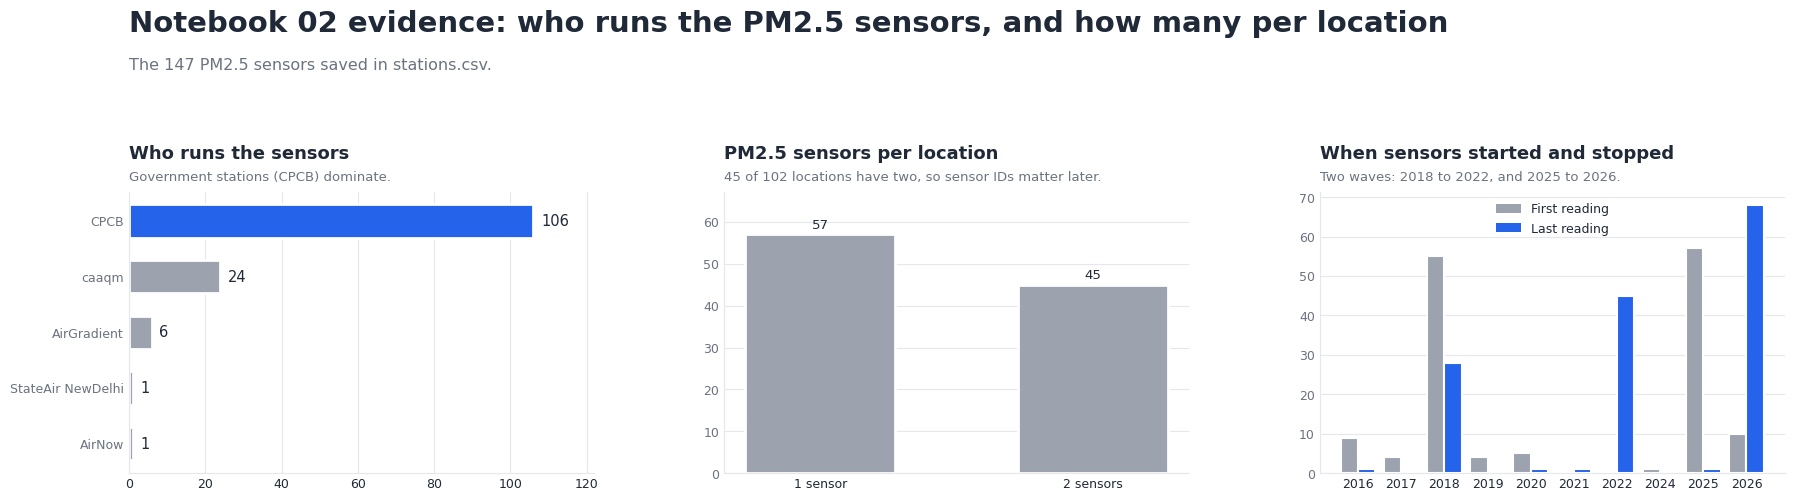

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import recap_style as rs

root = rs.find_project_root()
sensors = pd.read_csv(root / "data/raw/stations.csv", parse_dates=["first_reading", "last_reading"])

fig = plt.figure(figsize=(rs.FIG_W, 5.6), facecolor="white")
grid = fig.add_gridspec(1, 3, wspace=0.28, left=0.05, right=0.97, top=rs.top_margin(fig, 2.0), bottom=0.14)
rs.header(fig, "Notebook 02 evidence: who runs the PM2.5 sensors, and how many per location",
          f"The {len(sensors)} PM2.5 sensors saved in stations.csv.")

provider = fig.add_subplot(grid[0, 0])
counts = sensors["provider"].value_counts()
bars = provider.barh(counts.index[::-1], counts.values[::-1], color=[rs.ACCENT if name == "CPCB" else rs.BAR for name in counts.index[::-1]],
                     height=0.6, edgecolor="white", linewidth=2)
for bar, value in zip(bars, counts.values[::-1]):
    provider.text(value + 2, bar.get_y() + bar.get_height() / 2, str(value), va="center", fontsize=10.5, color=rs.INK)
provider.set_xlim(0, counts.max() * 1.15)
rs.style_axis(provider, "Who runs the sensors", "Government stations (CPCB) dominate.", grid_axis="x")

per_location = fig.add_subplot(grid[0, 1])
sensors_per_location = sensors.groupby("location_id").size().value_counts().sort_index()
bars = per_location.bar([f"{n} sensor{'s' if n > 1 else ''}" for n in sensors_per_location.index], sensors_per_location.values,
                        color=rs.BAR, width=0.55, edgecolor="white", linewidth=2)
per_location.set_ylim(0, sensors_per_location.max() * 1.18)
rs.label_bars(per_location, bars)
rs.style_axis(per_location, "PM2.5 sensors per location", "45 of 102 locations have two, so sensor IDs matter later.")

years = fig.add_subplot(grid[0, 2])
first_years = sensors["first_reading"].dt.year.value_counts().sort_index()
last_years = sensors["last_reading"].dt.year.value_counts().sort_index()
all_years = sorted(set(first_years.index) | set(last_years.index))
x = np.arange(len(all_years))
years.bar(x - 0.2, [first_years.get(y, 0) for y in all_years], width=0.4, color=rs.BAR, edgecolor="white", linewidth=1.5)
years.bar(x + 0.2, [last_years.get(y, 0) for y in all_years], width=0.4, color=rs.ACCENT, edgecolor="white", linewidth=1.5)
years.set_xticks(x, [str(int(y)) for y in all_years], fontsize=9)
rs.legend(years, [("First reading", rs.BAR, "bar"), ("Last reading", rs.ACCENT, "bar")], loc="upper center")
rs.style_axis(years, "When sensors started and stopped", "Two waves: 2018 to 2022, and 2025 to 2026.")
plt.show()

### Recap in five lines

1. The **API key stays in `.env`**. The notebook prints only whether it was found.
2. **One request helper** handles every outcome: stop on 401, wait and retry on 429, continue on 200.
3. The API returns **at most 100 locations a page**. A full first page is a signal to ask for the next one: 100 + 2 = 102 locations.
4. A location is a **station**, and a station carries **several sensors**. Keeping all 1,154 sensor rows, then filtering to PM2.5, leaves **147 sensors** at 102 locations.
5. Sensors come in **two waves**: many started in 2018 and stopped by 2022, and a newer group started in 2025 and is still reporting. That is why the next notebook checks coverage.

**If you remember only one thing:** when an API pages its results, a full page means "there is more". Loop until a page comes back short, or you silently lose rows.